
Suppose four symptoms tend to occur together:

- depressed mood
- loss of interest
- fatigue
- sleep problems

One possibility is that they partly reflect the same underlying condition. We cannot observe that common condition directly, so we represent it with a **latent factor**.

The simplest one-factor model is:

$$
Y_i = \lambda_iF + \epsilon_i
$$

Here:

- $Y_i$ is an observed variable, such as fatigue
- $F$ is the latent factor
- $\lambda_i$ is the factor loading
- $\epsilon_i$ is the part not explained by the factor

The factor loading tells us how strongly an observed variable is related to the latent factor.


## A picture of the model

The arrows from the factor to the symptoms represent the loadings.

Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.”


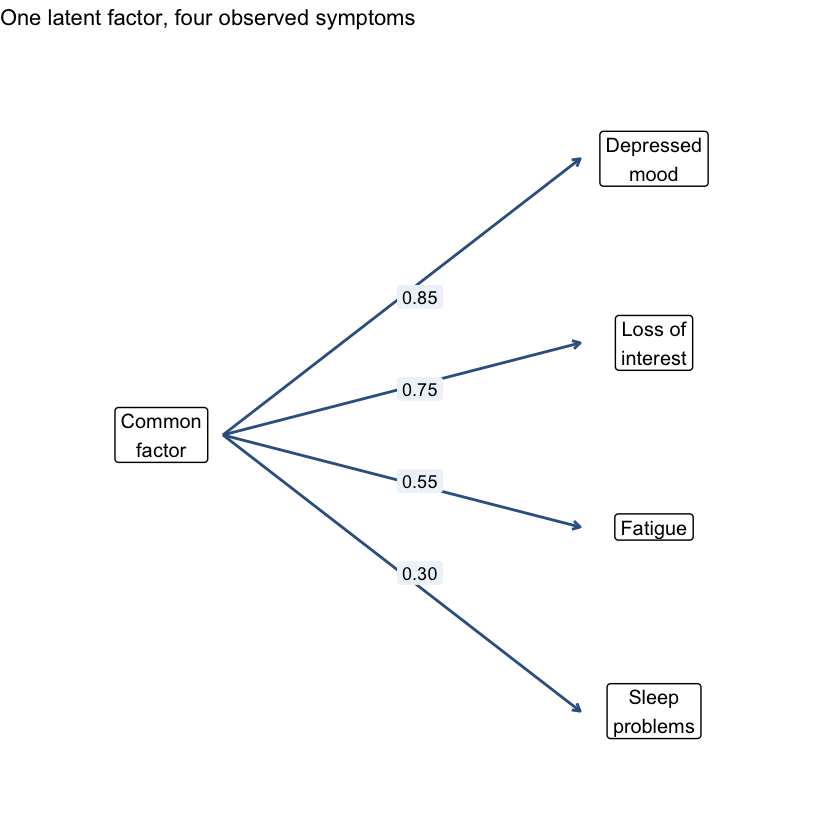

In [1]:
library(ggplot2)

nodes <- data.frame(
  label = c("Common\nfactor", "Depressed\nmood", "Loss of\ninterest",
            "Fatigue", "Sleep\nproblems"),
  x = c(0, 2, 2, 2, 2),
  y = c(2.5, 4, 3, 2, 1)
)

arrows <- data.frame(
  x = 0.25,
  xend = 1.70,
  y = 2.5,
  yend = c(4, 3, 2, 1),
  loading = c("0.85", "0.75", "0.55", "0.30")
)

ggplot() +
  geom_segment(
    data = arrows,
    aes(x = x, y = y, xend = xend, yend = yend),
    arrow = grid::arrow(length = grid::unit(0.18, "cm")),
    linewidth = 0.8,
    colour = "#35618f"
  ) +
  geom_label(
    data = nodes,
    aes(x = x, y = y, label = label),
    size = 4.2,
    label.size = 0.4,
    fill = "white"
  ) +
  geom_label(
    data = arrows,
    aes(x = 1.05, y = (y + yend) / 2, label = loading),
    size = 3.8,
    label.size = 0,
    fill = "#eef4fa"
  ) +
  coord_cartesian(xlim = c(-0.5, 2.6), ylim = c(0.5, 4.5)) +
  theme_void() +
  labs(title = "One latent factor, four observed symptoms")

A loading of $0.85$ indicates a stronger relationship with the factor than a loading of $0.30$. It does not mean that 85% of people have the symptom, or that the symptom is 85% genetic.

## Simulate a simple dataset

We will generate 1,000 observations from a model with one latent factor. The true loadings are $0.85$, $0.75$, $0.55$, and $0.30$.


In [2]:
set.seed(42)

n <- 1000
F <- rnorm(n)

dat <- data.frame(
  depressed_mood = 0.85 * F + sqrt(1 - 0.85^2) * rnorm(n),
  loss_interest  = 0.75 * F + sqrt(1 - 0.75^2) * rnorm(n),
  fatigue        = 0.55 * F + sqrt(1 - 0.55^2) * rnorm(n),
  sleep_problems = 0.30 * F + sqrt(1 - 0.30^2) * rnorm(n)
)

round(cor(dat), 2)

,depressed_mood,loss_interest,fatigue,sleep_problems
depressed_mood,1.00,0.62,0.51,0.26
loss_interest,0.62,1.00,0.40,0.20
fatigue,0.51,0.40,1.00,0.19
sleep_problems,0.26,0.20,0.19,1.00


In [ ]:

The expression $\sqrt{1-\lambda^2}$ sets the residual standard deviation. Each simulated variable therefore has variance close to 1.

The variables with higher loadings should have stronger correlations with one another. Sleep problems should have weaker correlations because its loading is only $0.30$.

## Visualization 1: the correlation heatmap

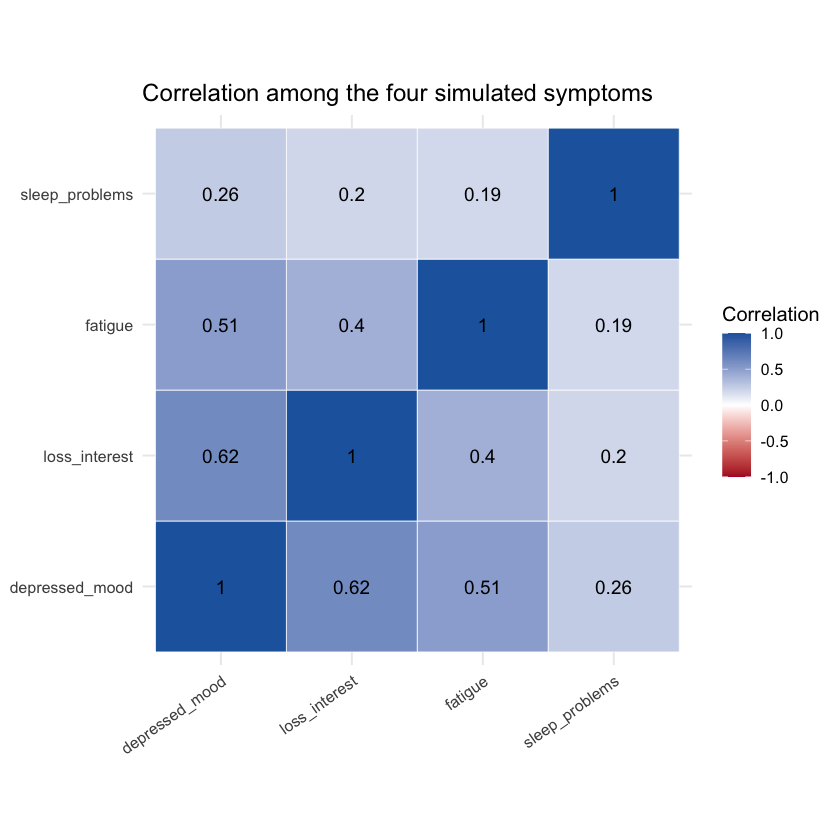

In [3]:
cor_mat <- round(cor(dat), 2)
cor_long <- as.data.frame(as.table(cor_mat))
names(cor_long) <- c("Variable_1", "Variable_2", "Correlation")

ggplot(cor_long, aes(Variable_1, Variable_2, fill = Correlation)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = Correlation), size = 4) +
  scale_fill_gradient2(
    low = "#b2182b", mid = "white", high = "#2166ac",
    midpoint = 0, limits = c(-1, 1)
  ) +
  coord_equal() +
  labs(
    title = "Correlation among the four simulated symptoms",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))





Why do the correlations follow this pattern? In a standardized one-factor model with uncorrelated residuals:

$$
\operatorname{Cor}(Y_i,Y_j) = \lambda_i\lambda_j
$$

For depressed mood and loss of interest, the expected correlation is:

$$
0.85 \times 0.75 = 0.6375
$$

For depressed mood and sleep problems, it is:

$$
0.85 \times 0.30 = 0.255
$$

The simulated correlations will be close to these values, but not identical, because the sample is finite.

## Fit the factor model

We can now pretend that the latent factor and its loadings are unknown. We will estimate them using confirmatory factor analysis in `lavaan`.

In [4]:
install.packages("lavaan")   # run once if lavaan is not installed
library(lavaan)

model <- '
  common_factor =~ depressed_mood + loss_interest + fatigue + sleep_problems
'

fit <- cfa(
  model,
  data = dat,
  std.lv = TRUE
)

summary(fit, standardized = TRUE, fit.measures = TRUE)




The downloaded binary packages are in
	/var/folders/vm/xtvv8jb542s04t61c12lsnvr0000gn/T//RtmpioPYkf/downloaded_packages


This is lavaan 0.7-2
lavaan is FREE software! Please report any bugs.



lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
common_factor,=~,depressed_mood,0,0.8848479,0.03287643,26.914352,0.000000e+00,0.8848479,0.8831726
common_factor,=~,loss_interest,0,0.7055742,0.03259539,21.646445,0.000000e+00,0.7055742,0.7034063
common_factor,=~,fatigue,0,0.5753339,0.03244199,17.734240,0.000000e+00,0.5753339,0.5754001
common_factor,=~,sleep_problems,0,0.3020503,0.03448501,8.758885,0.000000e+00,0.3020503,0.2972287
depressed_mood,~~,depressed_mood,0,0.2208417,0.03955916,5.582567,2.369947e-08,0.2208417,0.2200062
loss_interest,~~,loss_interest,0,0.5083386,0.03353475,15.158564,0.000000e+00,0.5083386,0.5052196
fatigue,~~,fatigue,0,0.6687610,0.03440072,19.440319,0.000000e+00,0.6687610,0.6689147
sleep_problems,~~,sleep_problems,0,0.9414719,0.04297095,21.909498,0.000000e+00,0.9414719,0.9116551
common_factor,~~,common_factor,0,1.0000000,0.00000000,NA,NA,1.0000000,1.0000000



`std.lv = TRUE` fixes the variance of the latent factor to 1. This gives the factor a scale while allowing all four loadings to be estimated.

Extract the standardized loadings:

In [5]:
loading_table <- parameterEstimates(
  fit,
  standardized = TRUE
)

loading_table <- subset(
  loading_table,
  op == "=~",
  select = c("rhs", "est", "se", "pvalue", "std.all")
)

names(loading_table) <- c(
  "Symptom", "Unstandardized_loading", "SE", "P_value",
  "Standardized_loading"
)

loading_table

,Symptom,Unstandardized_loading,SE,P_value,Standardized_loading
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,depressed_mood,0.8848479,0.03287643,0,0.8831726
2,loss_interest,0.7055742,0.03259539,0,0.7034063
3,fatigue,0.5753339,0.03244199,0,0.5754001
4,sleep_problems,0.3020503,0.03448501,0,0.2972287




Because the data were simulated, the estimated standardized loadings should be reasonably close to the true values. They will not match them exactly.

## Visualization 2: compare the loadings

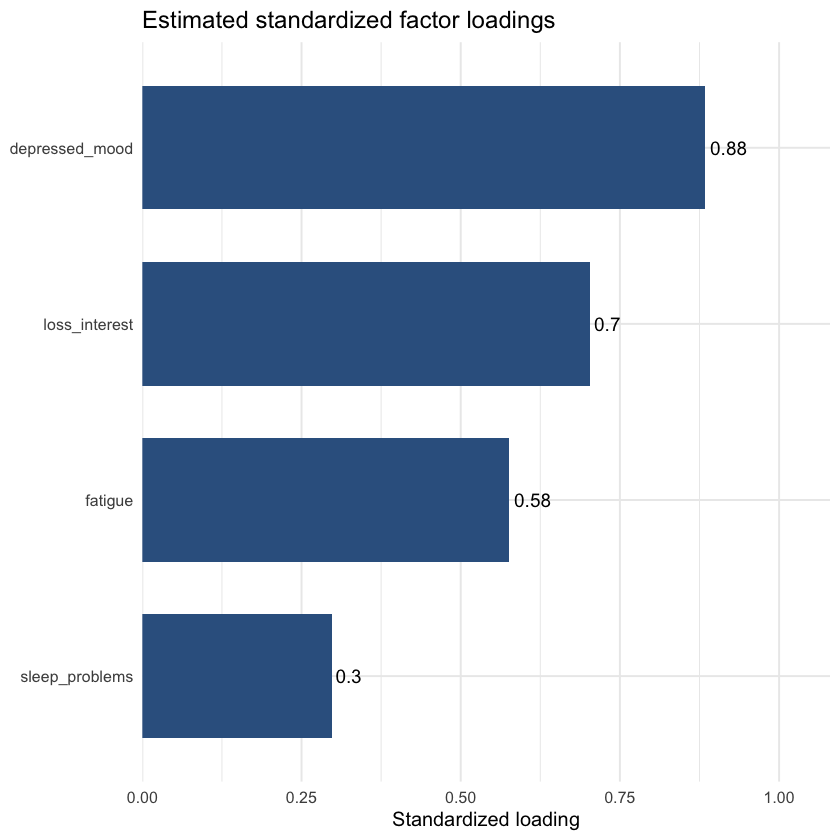

In [6]:
ggplot(
  loading_table,
  aes(x = reorder(Symptom, Standardized_loading),
      y = Standardized_loading)
) +
  geom_col(fill = "#35618f", width = 0.7) +
  geom_text(
    aes(label = round(Standardized_loading, 2)),
    hjust = -0.15,
    size = 4
  ) +
  coord_flip() +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.08))) +
  labs(
    title = "Estimated standardized factor loadings",
    x = NULL,
    y = "Standardized loading"
  ) +
  theme_minimal(base_size = 12)

This plot makes the main result easy to see. Depressed mood and loss of interest are strong indicators of the common factor. Sleep problems are related to it more weakly.

A low loading does not mean that a variable is unimportant. It means that less of its variation follows this particular common factor.

## Squaring a standardized loading

In this one-factor standardized model, the squared loading is the proportion of an observed variable's variance explained by the factor.

For a loading of $0.80$:

$$
0.80^2 = 0.64
$$

The factor explains 64% of the variable's variance. The remaining 36% is residual variance:

$$
1 - 0.64 = 0.36
$$

This interpretation applies to standardized loadings in the simple model used here. With multiple factors, the communality depends on all relevant loadings and on correlations between factors. Do not square an unstandardized loading and automatically interpret it as a percentage.

## Visualization 3: shared and residual variance

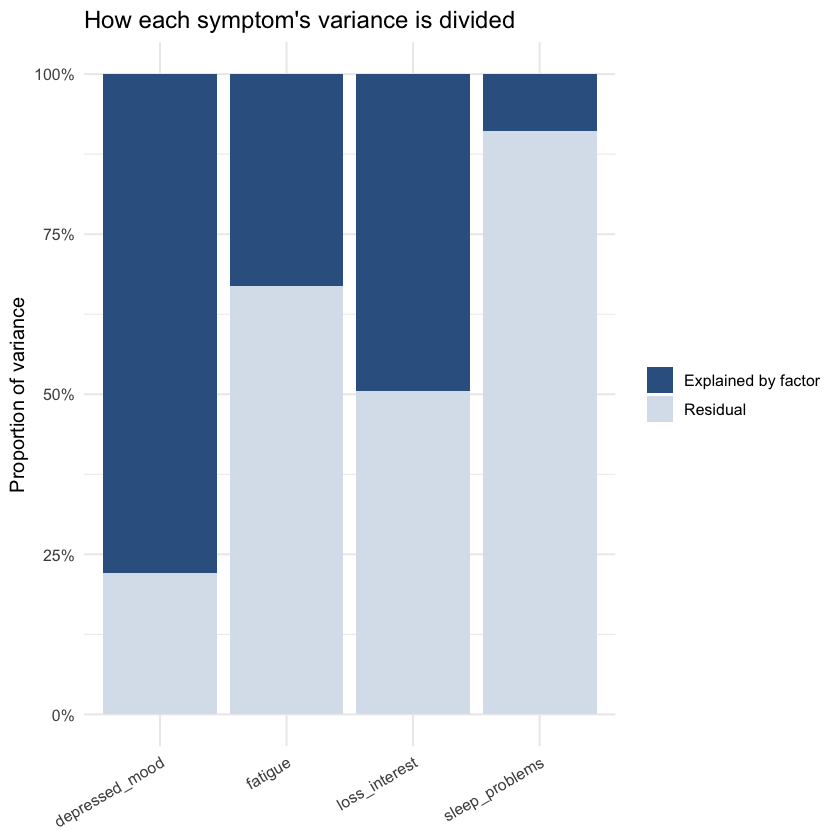

In [7]:
variance_table <- data.frame(
  Symptom = loading_table$Symptom,
  Shared = loading_table$Standardized_loading^2
)

variance_table$Residual <- 1 - variance_table$Shared

variance_long <- reshape(
  variance_table,
  varying = c("Shared", "Residual"),
  v.names = "Proportion",
  timevar = "Variance_type",
  times = c("Explained by factor", "Residual"),
  direction = "long"
)

ggplot(
  variance_long,
  aes(x = Symptom, y = Proportion, fill = Variance_type)
) +
  geom_col() +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_manual(values = c("#35618f", "#d9e2ec")) +
  labs(
    title = "How each symptom's variance is divided",
    x = NULL,
    y = "Proportion of variance",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))


This is the same information as the loading plot, but expressed as variance. The change is nonlinear: a loading of $0.80$ explains much more variance than a loading of $0.40$.

## Visualization 4: loading versus explained variance

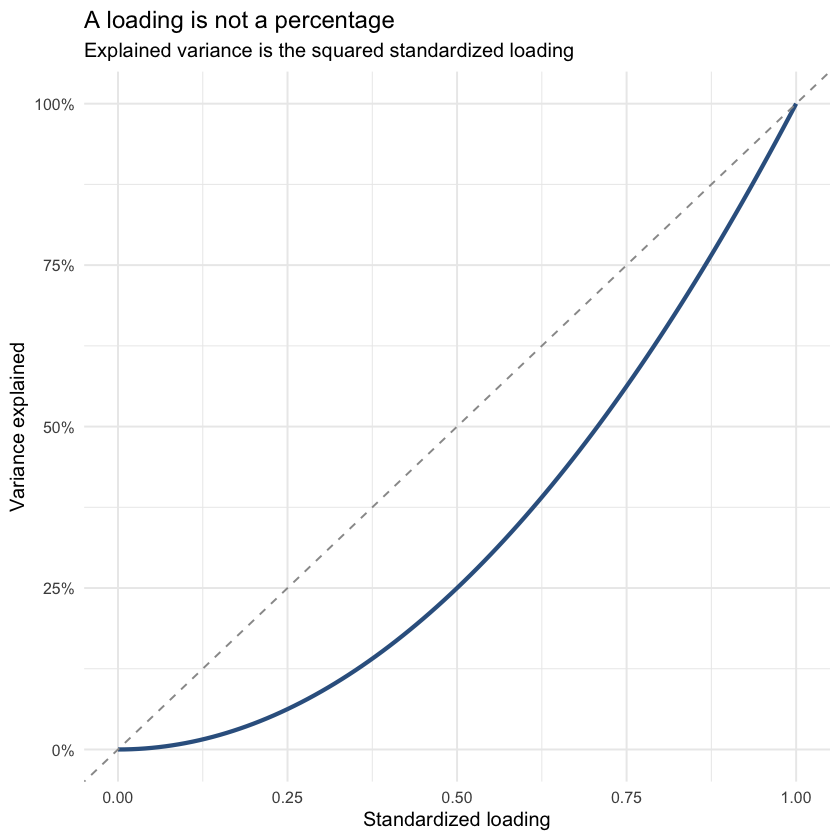

In [8]:

loading_curve <- data.frame(
  Loading = seq(0, 1, by = 0.01)
)

loading_curve$Explained_variance <- loading_curve$Loading^2

ggplot(loading_curve, aes(Loading, Explained_variance)) +
  geom_line(linewidth = 1.2, colour = "#35618f") +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = "dashed",
    colour = "grey60"
  ) +
  scale_x_continuous(limits = c(0, 1)) +
  scale_y_continuous(
    limits = c(0, 1),
    labels = scales::percent_format()
  ) +
  labs(
    title = "A loading is not a percentage",
    subtitle = "Explained variance is the squared standardized loading",
    x = "Standardized loading",
    y = "Variance explained"
  ) +
  theme_minimal(base_size = 12)


The dashed line shows the common mistake of reading a loading directly as a percentage. The solid curve shows the correct squared relationship for this model.

## What about negative loadings?

A loading can be negative. A negative loading means that higher values of the factor are associated with lower values of the observed variable.

For example, wellbeing might load negatively on a general distress factor:

$$
\lambda_{\text{wellbeing}}=-0.70
$$

The sign of an entire latent factor is arbitrary. Multiplying every loading by $-1$ describes the same covariance pattern. What matters is whether variables point in the same or opposite directions relative to one another.



## The Genomic SEM context

The example above uses measurements from individuals. Genomic SEM works at a different level.

It first uses GWAS summary statistics to estimate a genetic covariance matrix. The diagonal contains SNP-based genetic variances, and the off-diagonal entries contain genetic covariances between traits. Genomic SEM then asks whether one or more latent factors can explain that covariance pattern.

For four GWAS phenotypes, the model is still written conceptually as:

$$
Y_i = \lambda_iF_g + \epsilon_i
$$

But now:

- $Y_i$ represents the genetic component of a GWAS phenotype
- $F_g$ is a latent genetic factor
- $\lambda_i$ describes how strongly the phenotype's genetic component reflects that factor
- $\epsilon_i$ is residual genetic variation not explained by the factor

Suppose the standardized genetic loading for fatigue is $0.70$. This does not mean that fatigue is 70% heritable. It means that fatigue's genetic component is strongly related to the latent genetic factor, under the fitted model.

Genomic SEM also uses the sampling covariance matrix produced by multivariable LDSC. This allows the model to account for uncertainty in the estimated genetic covariances and for correlated sampling error caused by overlapping GWAS samples.

The small `lavaan` analysis in this tutorial teaches how factor loadings behave. It is not a replacement for a Genomic SEM analysis. A real Genomic SEM workflow starts from harmonized GWAS summary statistics, estimates the genetic and sampling covariance matrices, and fits the model to those matrices.

## Factor loading versus PCA weight

Factor analysis and principal component analysis are related, but they do not ask the same question.

- PCA constructs a weighted combination that captures as much total variation as possible.
- Factor analysis estimates a latent variable intended to explain shared covariance among the observed variables.

A PCA weight tells us how a variable contributes to constructing a component. A factor loading tells us how strongly an observed variable reflects an inferred factor.

For Genomic SEM, the second question is usually the one of interest: what latent genetic structure can explain why several GWAS phenotypes are genetically correlated?

## What to check when interpreting loadings

Do not judge a model from the loading sizes alone. Also check:

- standard errors and confidence intervals
- whether the signs make scientific sense
- overall model fit
- residual variances and residual covariances
- whether one trait dominates the factor
- whether a second factor gives a clearer structure
- GWAS sample size and SNP-heritability precision

The name assigned to a factor is an interpretation, not something discovered automatically by the software. The loading pattern tells us which traits define the factor. Scientific knowledge tells us what that pattern may represent.



## References

1. Grotzinger, A. D., et al. (2019). [Genomic structural equation modelling provides insights into the multivariate genetic architecture of complex traits](https://doi.org/10.1038/s41562-019-0566-x). *Nature Human Behaviour*, 3, 513–525.
2. Rosseel, Y. [The lavaan confirmatory factor analysis tutorial](https://lavaan.ugent.be/tutorial/cfa.html).
3. UCLA Statistical Consulting. [A practical introduction to factor analysis](https://stats.oarc.ucla.edu/spss/seminars/introduction-to-factor-analysis/).
